# A Strait Apart: Brent Prices and Vessel Traffic During the 2026 Hormuz Disruption

**DSM050 Data Visualisation, Final Coursework (CW2)**

**Why this investigation?** On 28 February 2026 daily recorded transits through the Strait of Hormuz began falling from 57 to single digits within three days. Brent later peaked 103% above its pre closure median, then reversed about two thirds of that rise while recorded traffic remained low. This analysis examines the difference between the price response and observed throughput.

**Who is this for?** Energy market analysts and policy researchers studying maritime throughput and crude pricing during a sustained disruption.

**What does it produce?**

- A measure of the collapse, split by vessel class
- Cumulative transit shortfall under two baseline assumptions
- Tests for weekday differences before and during the closure
- A comparison of crude prices and AIS recorded throughput
- Lag correlations and vessel mix profiles across regimes

- **Primary dataset**: straits.live Strait of Hormuz open data mirror, derived from IMF PortWatch AIS transit counts

Sections 1 to 3 cover the research questions, data sources and pre processing. Section 4 and 5 presents the analysis and findings conclusion.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.tsa.stattools import acf

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

data_dir = Path("../dataset/straits_live")
fig_dir = Path("figures")
out_dir = Path("outputs")
fig_dir.mkdir(exist_ok=True)
out_dir.mkdir(exist_ok=True)

# cw1 feedback flagged redundant gridlines and chart furniture, so defaults are stripped back here
mpl.rcParams.update({
    "figure.dpi": 110
    , "savefig.dpi": 200
    , "savefig.bbox": "tight"
    , "font.size": 10
    , "axes.spines.top": False
    , "axes.spines.right": False
    , "axes.grid": False
    , "axes.titlesize": 11
    , "axes.titleweight": "bold"
})

# closure begins 28 feb 2026; publisher's pre-crisis window ends the day before
crisis_onset = pd.Timestamp("2026-02-28")
pre_crisis_end = pd.Timestamp("2026-02-27")

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.3 | numpy 2.5.1


## 1. Research topic and background

The Strait of Hormuz connects the Persian Gulf to the Arabian Sea. Its narrow navigable channel makes it a chokepoint in global energy logistics.

This investigation compares recorded vessel movements with crude prices during the 2026 disruption. Daily transit counts measure AIS visible throughput. A supplementary daily Brent series covers the price reaction that the supplied hourly feed misses.

The aim is to establish how price and recorded traffic changed, and whether they recovered together. The study is observational and has no comparison chokepoint, so it cannot isolate the closure's causal effect on prices.

The five research questions appear at the end of Section 3, after the coverage and quality checks.

## 2. Data sources

The five primary files come from the straits.live open data mirror. Transit counts are derived from IMF PortWatch for chokepoint 6. The supplied price feed contains Brent and WTI quotes sampled on a roughly hourly schedule. A separate FRED Brent spot series supplements that feed.

The data consists of machine collected vessel telemetry and market prices. It contains no personal data. The checks below focus on coverage, stale quotes and consistency between sources.

In [2]:
# 2.1 load raw sources exactly as supplied, no parsing yet
transits_raw = pd.read_csv(data_dir / "straits-transits.csv")
oil_raw = pd.read_csv(data_dir / "straits-oil.csv")
index_raw = pd.read_csv(data_dir / "straits-hormuz-index.csv")
events_raw = pd.read_csv(data_dir / "straits-events.csv")

with open(data_dir / "transits.json") as f:
    transits_json = json.load(f)

for name, df in [
    ("straits-transits.csv", transits_raw)
    , ("straits-oil.csv", oil_raw)
    , ("straits-hormuz-index.csv", index_raw)
    , ("straits-events.csv", events_raw)
]:
    print(f"{name:26s} {df.shape[0]:5d} rows x {df.shape[1]} cols   {list(df.columns)}")

straits-transits.csv         512 rows x 4 cols   ['date', 'n_total', 'n_tanker', 'n_cargo']
straits-oil.csv             2350 rows x 3 cols   ['timestamp_iso', 'brent_usd', 'wti_usd']
straits-hormuz-index.csv    2015 rows x 5 cols   ['timestamp_iso', 'crisis_pressure', 'crisis_band', 'escalation_forecast', 'forecast_band']
straits-events.csv            53 rows x 9 cols   ['occurred_at_iso', 'type', 'severity', 'title', 'description', 'lat', 'lng', 'source_name', 'source_url']


In [3]:
# 2.2 publisher provenance and the documented baseline anchors
latest = transits_json["latest"]

print("source     :", latest["sourceName"], "|", latest["sourceUrl"])
print("as of      :", transits_json["asOf"], "| flagged stale:", transits_json["stale"])
print("age (days) :", transits_json["asOfAgeDays"])
print()
print("publisher pre-crisis baseline median (365d to 2026-02-27):", latest["preCrisisBaselineMedian"])
print("publisher rolling 30-day baseline median                :", latest["baselineMedian"])
print()
print("methodology note:")
print(transits_json["methodology"])

source     : IMF PortWatch | https://portwatch.imf.org/pages/chokepoint6
as of      : 2026-08-30T17:54:25.761Z | flagged stale: False
age (days) : 7

publisher pre-crisis baseline median (365d to 2026-02-27): 85
publisher rolling 30-day baseline median                : 5

methodology note:
IMF PortWatch daily vessel transit count for chokepoint6 (Strait of Hormuz), derived from global AIS via Oxford / UN Global Pulse. preCrisisBaselineMedian is the median nTotal across the final 365 pre-crisis days (2025-02-28 through 2026-02-27), a fixed date-bounded window so the sample cannot shrink over time; the stable peacetime anchor for throughput-% computation. baselineMedian is the rolling 30-day median (average of the two middle values on an even-length window); it drifts downward as a sustained closure becomes the new normal. This value is kept aligned with the same chokepoint's entry in /api/v1/chokepoints. The per-type fields nest: nTotal is nTanker plus nCargo, and nCargo is nContainer p

In [4]:
# 2.3 does the json history extend the csv, or merely duplicate it?
json_hist = pd.DataFrame(transits_json["history"])
json_dates = set(json_hist["date"])
csv_dates = set(transits_raw["date"])

print("json history rows :", len(json_hist))
print("csv rows          :", len(transits_raw))
print("dates only in json:", len(json_dates - csv_dates))
print("dates only in csv :", len(csv_dates - json_dates))

shared = json_hist.merge(transits_raw, on="date", how="inner")
mismatches = shared.loc[shared["nTotal"] != shared["n_total"]]
print("shared dates      :", len(shared))
print("value mismatches  :", len(mismatches))

json history rows : 365
csv rows          : 512
dates only in json: 0
dates only in csv : 147
shared dates      : 365
value mismatches  : 0


### 2.4 Coverage audit

The supplied sources differ in cadence and coverage. Checking their dates before choosing the analyses identifies which comparisons the files can support.

In [5]:
# 2.4 coverage audit across all four time-stamped sources
def coverage(name, raw_series, cadence):
    s = pd.to_datetime(raw_series, format="ISO8601", utc=True)
    return {
        "source": name
        , "cadence": cadence
        , "rows": len(s)
        , "first": s.min().date()
        , "last": s.max().date()
        , "span_days": (s.max() - s.min()).days + 1
        , "distinct_days": s.dt.date.nunique()
    }

coverage_tbl = pd.DataFrame([
    coverage("transits", transits_raw["date"], "daily")
    , coverage("oil", oil_raw["timestamp_iso"], "~hourly")
    , coverage("hormuz index", index_raw["timestamp_iso"], "5-minute")
    , coverage("events", events_raw["occurred_at_iso"], "irregular")
])

coverage_tbl.to_csv(out_dir / "coverage_audit.csv", index=False)
display(coverage_tbl)

,source,cadence,rows,first,last,span_days,distinct_days
0,transits,daily,512,2025-03-30,2026-08-23,512,512
1,oil,~hourly,2350,2026-05-05,2026-08-28,116,113
2,hormuz index,5-minute,2015,2026-08-23,2026-08-30,7,8
3,events,irregular,53,2026-08-28,2026-08-30,3,3


### 2.5 Supporting price series

The supplied price feed begins on 5 May 2026, nine weeks after closure onset. It cannot show the initial market reaction. A daily Brent spot series was therefore retrieved through FRED (series `DCOILBRENTEU`, sourced from the US Energy Information Administration).

Straits.live remains the primary dataset. FRED provides the earlier price history and a separate source for comparison during the overlapping period. The FRED series reports business day observations, so weekends and public holidays do not represent missing transit records.

In [6]:
# 2.5 supporting daily brent series covering the pre-closure gap
brent_fred = pd.read_csv(Path("../dataset/fred/brent_daily_2025_2026.csv"))
brent_fred.columns = ["date", "brent"]
brent_fred["date"] = pd.to_datetime(brent_fred["date"])
brent_fred["brent"] = pd.to_numeric(brent_fred["brent"], errors="coerce")

print(f"rows supplied     : {len(brent_fred)}")
print(f"non-numeric cells : {int(brent_fred['brent'].isna().sum())} (FRED marks holidays with '.')")

brent_fred = brent_fred.dropna().set_index("date").sort_index()

print(f"usable rows       : {len(brent_fred)}")
print(f"period            : {brent_fred.index.min().date()} -> {brent_fred.index.max().date()}")
print(f"calendar days     : {(brent_fred.index.max() - brent_fred.index.min()).days + 1} (business-day series)")
print(f"pre-closure median: {brent_fred.loc[:pre_crisis_end, 'brent'].median():.2f} USD/bbl")

rows supplied     : 429
non-numeric cells : 12 (FRED marks holidays with '.')
usable rows       : 417
period            : 2025-01-02 -> 2026-08-25
calendar days     : 601 (business-day series)
pre-closure median: 68.14 USD/bbl


## 3. Data overview and pre processing

### 3.1 Transit integrity checks

The transit file is checked for calendar gaps, duplicates, nulls, negative counts and internal consistency. The publisher states that `n_total` should equal `n_tanker` plus `n_cargo`, which gives a testable check on every record.

In [7]:
# 3.1 transits: parse, index, and verify integrity
transits = transits_raw.copy()
transits["date"] = pd.to_datetime(transits["date"])
transits = transits.sort_values("date").set_index("date")

full_range = pd.date_range(transits.index.min(), transits.index.max(), freq="D")
missing_days = full_range.difference(transits.index)

print(f"observed period   : {transits.index.min().date()} -> {transits.index.max().date()}")
print(f"expected days     : {len(full_range)}")
print(f"observed days     : {len(transits)}")
print(f"missing days      : {len(missing_days)}")
print(f"duplicate dates   : {int(transits.index.duplicated().sum())}")
print(f"null cells        : {int(transits.isna().sum().sum())}")
print(f"negative counts   : {int((transits < 0).sum().sum())}")

invariant_breaks = transits.loc[transits["n_total"] != transits["n_tanker"] + transits["n_cargo"]]
print(f"rows breaking n_total = n_tanker + n_cargo : {len(invariant_breaks)}")

observed period   : 2025-03-30 -> 2026-08-23
expected days     : 512
observed days     : 512
missing days      : 0
duplicate dates   : 0
null cells        : 0
negative counts   : 0
rows breaking n_total = n_tanker + n_cargo : 0


### 3.2 Baseline definition

Any estimate of throughput as a percentage of normal depends on the baseline. The median of the available pre crisis observations is computed and compared with the publisher's figure. Close agreement supports consistency between the calculations, but does not independently validate AIS coverage.

The pre closure series trends downward. Both the annual anchor and a 90 day pre closure anchor are therefore retained to show how baseline choice affects the estimated shortfall.

In [8]:
# 3.2 independent baseline, cross-checked against the published figure
pre_crisis = transits.loc[:pre_crisis_end]
baseline_median = pre_crisis["n_total"].median()
baseline_mean = pre_crisis["n_total"].mean()
publisher_baseline = latest["preCrisisBaselineMedian"]

print(f"pre-crisis days held      : {len(pre_crisis)}")
print(f"our baseline median       : {baseline_median:.1f}")
print(f"publisher baseline median : {publisher_baseline}")
print(f"difference                : {baseline_median - publisher_baseline:+.1f}")
print(f"our baseline mean         : {baseline_mean:.1f}")
print()

# traffic was already drifting down before the closure, so a single median hides a trend
quarterly = pre_crisis["n_total"].resample("QE").agg(["count", "median", "mean"]).round(1)
print("pre-crisis quarterly profile:")
display(quarterly)

# the pre-crisis series is not stationary, so a second anchor is carried for sensitivity testing
baseline_90d = transits.loc[pre_crisis_end - pd.Timedelta(days=89):pre_crisis_end, "n_total"].median()
print(f"alternative 90-day pre-closure baseline median : {baseline_90d:.1f}")
print(f"annual anchor exceeds 90-day anchor by         : {100 * (baseline_median / baseline_90d - 1):+.1f}%")

pre-crisis days held      : 335
our baseline median       : 86.0
publisher baseline median : 85
difference                : +1.0
our baseline mean         : 85.1

pre-crisis quarterly profile:


,count,median,mean
date,,,
2025-03-31,2,101.5,101.5
2025-06-30,91,107.0,104.7
2025-09-30,92,90.0,90.3
2025-12-31,92,66.5,70.8
2026-03-31,58,63.5,68.1


alternative 90-day pre-closure baseline median : 61.0
annual anchor exceeds 90-day anchor by         : +41.0%


### 3.3 Derived variables and regime segmentation

The derived measures include rolling means, throughput relative to baseline, tanker share and cumulative transit shortfall. Regime classification uses the smoothed transit series, with the first three days from onset treated separately as collapse. This keeps the initial fall distinct from the later partial recovery.

In [9]:
# 3.3 derived measures
transits["roll7"] = transits["n_total"].rolling(7, center=True, min_periods=4).mean()
transits["pct_of_baseline"] = 100 * transits["n_total"] / baseline_median
transits["roll7_pct_baseline"] = 100 * transits["roll7"] / baseline_median
transits["tanker_share"] = np.where(transits["n_total"] > 0, transits["n_tanker"] / transits["n_total"], np.nan)
transits["deficit_vs_baseline"] = baseline_median - transits["n_total"]

# lost vessel-days only accrue from the closure onward
transits["cum_deficit"] = transits["deficit_vs_baseline"].where(transits.index >= crisis_onset, 0).cumsum()

transits["dow"] = transits.index.day_name()
transits["dow_num"] = transits.index.dayofweek
transits["iso_year"] = transits.index.isocalendar().year.values
transits["iso_week"] = transits.index.isocalendar().week.values

# regimes are contiguous: collapse ends the first day the smoothed series drops below 20% of baseline
post_onset = transits.loc[transits.index >= crisis_onset]
collapse_complete = post_onset.loc[post_onset["roll7_pct_baseline"] < 20].index.min()

transits["regime"] = np.select(
    [
        transits.index <= pre_crisis_end
        , transits.index < collapse_complete
        , transits["roll7_pct_baseline"] >= 20
    ]
    , ["pre-crisis", "collapse", "partial recovery"]
    , default="closure"
)

print(f"collapse completed on: {collapse_complete.date()}")
print()
print(transits["regime"].value_counts().to_string())
print()
print("regime date ranges:")
for r in ["pre-crisis", "collapse", "closure", "partial recovery"]:
    g = transits.loc[transits["regime"] == r]
    print(f"  {r:18s} {g.index.min().date()} -> {g.index.max().date()}  (n={len(g)})")

collapse completed on: 2026-03-03

regime
pre-crisis          335
closure             157
partial recovery     17
collapse              3

regime date ranges:
  pre-crisis         2025-03-30 -> 2026-02-27  (n=335)
  collapse           2026-02-28 -> 2026-03-02  (n=3)
  closure            2026-03-03 -> 2026-08-23  (n=157)
  partial recovery   2026-06-21 -> 2026-07-07  (n=17)


### 3.4 Stale quotes and price artefacts

Long runs of identical quotes suggest that cached values were served repeatedly. Some isolated observations also return to earlier price levels. These features can distort daily summaries.

Stale observations are flagged and excluded before resampling. A daily median is used because it is less sensitive than a mean to isolated artefact ticks that survive the filter.

In [10]:
# 3.4 oil: detect stale carry-forward quotes before any resampling
oil = oil_raw.copy()
oil["timestamp"] = pd.to_datetime(oil["timestamp_iso"], format="ISO8601", utc=True)
oil = oil.sort_values("timestamp").set_index("timestamp")

is_repeat = (oil["brent_usd"].diff() == 0) & (oil["wti_usd"].diff() == 0)
run_id = (~is_repeat).cumsum()
run_len = oil.groupby(run_id)["brent_usd"].transform("size")

oil["is_repeat"] = is_repeat
oil["run_len"] = run_len
oil["is_stale"] = is_repeat & (run_len >= 6)

print(f"observations              : {len(oil)}")
print(f"distinct brent values     : {oil['brent_usd'].nunique()}")
print(f"exact repeats of previous : {int(is_repeat.sum())} ({100 * is_repeat.mean():.1f}%)")
print(f"longest identical run     : {int(run_len.max())} observations")
print(f"flagged stale             : {int(oil['is_stale'].sum())} ({100 * oil['is_stale'].mean():.1f}%)")
print()
print("longest flat runs:")
top_runs = (
    oil.loc[oil["run_len"] >= 20]
    .groupby(run_id.loc[oil["run_len"] >= 20])
    .agg(brent=("brent_usd", "first"), n_obs=("brent_usd", "size"), start=("brent_usd", lambda s: s.index.min().date()), end=("brent_usd", lambda s: s.index.max().date()))
    .sort_values("n_obs", ascending=False)
    .head(8)
)
display(top_runs)

observations              : 2350
distinct brent values     : 1187
exact repeats of previous : 727 (30.9%)
longest identical run     : 145 observations
flagged stale             : 704 (30.0%)

longest flat runs:


,brent,n_obs,start,end
199,116.73,145,2026-05-20,2026-05-26
198,111.37,102,2026-05-16,2026-05-20
392,93.09,50,2026-06-05,2026-06-07
511,87.33,42,2026-06-13,2026-06-14
935,88.10,42,2026-07-18,2026-07-19
1050,96.78,42,2026-07-25,2026-07-26
1170,87.93,42,2026-08-01,2026-08-02
277,91.12,39,2026-05-30,2026-05-31


In [11]:
# 3.5 resample the surviving hourly quotes to a daily series
oil_live = oil.loc[~oil["is_stale"]]

oil_daily = pd.DataFrame({
    "brent_median": oil_live["brent_usd"].resample("D").median()
    , "brent_min": oil_live["brent_usd"].resample("D").min()
    , "brent_max": oil_live["brent_usd"].resample("D").max()
    , "wti_median": oil_live["wti_usd"].resample("D").median()
    , "n_obs": oil_live["brent_usd"].resample("D").size()
})
oil_daily.index = oil_daily.index.tz_localize(None).normalize()
oil_daily["brent_intraday_range"] = oil_daily["brent_max"] - oil_daily["brent_min"]
oil_daily["brent_logret"] = np.log(oil_daily["brent_median"]).diff()
oil_daily["brent_vol_7d"] = oil_daily["brent_logret"].rolling(7).std() * np.sqrt(365) * 100

print(f"daily rows          : {len(oil_daily)}")
print(f"period              : {oil_daily.index.min().date()} -> {oil_daily.index.max().date()}")
print(f"days with no live quote: {int((oil_daily['n_obs'] == 0).sum())}")
print(f"brent first / last  : {oil_daily['brent_median'].iloc[0]:.2f} -> {oil_daily['brent_median'].iloc[-1]:.2f}")
print(f"change over window  : {100 * (oil_daily['brent_median'].iloc[-1] / oil_daily['brent_median'].iloc[0] - 1):+.1f}%")
print()
display(oil_daily[["brent_median", "wti_median", "n_obs", "brent_intraday_range", "brent_vol_7d"]].describe().round(2))

daily rows          : 116
period              : 2026-05-05 -> 2026-08-28
days with no live quote: 14
brent first / last  : 110.36 -> 89.30
change over window  : -19.1%



,brent_median,wti_median,n_obs,brent_intraday_range,brent_vol_7d
count,102.00,102.00,116.00,102.00,48.00
mean,88.44,83.68,14.19,3.59,49.27
std,10.17,9.70,10.14,4.50,16.53
min,71.06,68.09,0.00,0.00,20.92
25%,80.51,76.27,2.00,1.09,37.48
50%,88.86,83.20,20.00,2.50,50.40
75%,93.85,89.59,24.00,3.98,56.00
max,116.73,112.25,24.00,24.19,98.11


### 3.5b Comparing the two price sources

The two series measure different instruments. Straits.live quotes front month futures sampled intraday, while FRED reports Brent spot Europe daily. A price difference between them is therefore possible even when both are recorded correctly.

The comparison checks whether their levels and movements agree across the overlapping dates. Agreement supports using FRED as the supplementary series, but does not make the two instruments interchangeable.

overlapping days : 76
pearson r        : 0.9675
mean abs diff    : 2.95 USD/bbl
median bias      : -1.58 USD/bbl
max abs diff     : 9.45 USD/bbl


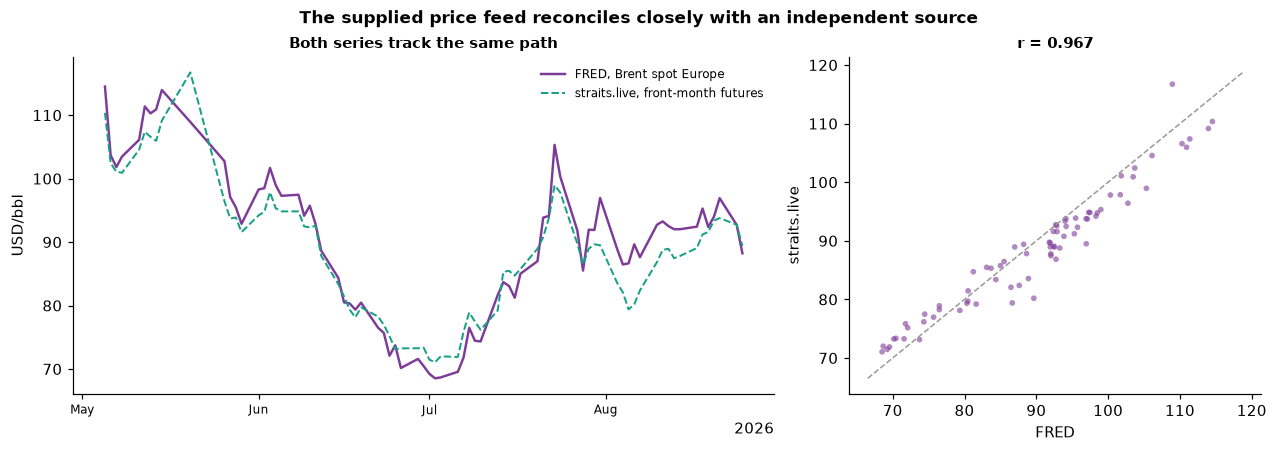

In [12]:
# 3.5b reconcile the primary feed against the independent series
import matplotlib.dates as mdates

recon = pd.DataFrame({
    "fred": brent_fred["brent"]
    , "straits": oil_daily["brent_median"]
}).dropna()
recon["diff"] = recon["straits"] - recon["fred"]

print(f"overlapping days : {len(recon)}")
print(f"pearson r        : {recon['fred'].corr(recon['straits']):.4f}")
print(f"mean abs diff    : {recon['diff'].abs().mean():.2f} USD/bbl")
print(f"median bias      : {recon['diff'].median():+.2f} USD/bbl")
print(f"max abs diff     : {recon['diff'].abs().max():.2f} USD/bbl")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), gridspec_kw={"width_ratios": [1.7, 1]}, layout="constrained")
axes[0].plot(recon.index, recon["fred"], color="#7d3c98", lw=1.6, label="FRED, Brent spot Europe")
axes[0].plot(recon.index, recon["straits"], color="#16a085", lw=1.3, ls="--", label="straits.live, front-month futures")
axes[0].set_ylabel("USD/bbl")
axes[0].legend(frameon=False, loc="upper right", fontsize=8)
axes[0].set_title("Both series track the same path", fontsize=10)
date_locator = mdates.AutoDateLocator(minticks=3, maxticks=5)
axes[0].xaxis.set_major_locator(date_locator)
axes[0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(date_locator))
axes[0].tick_params(axis="x", labelsize=8)

axes[1].scatter(recon["fred"], recon["straits"], s=14, color="#7d3c98", alpha=0.6, edgecolors="none")
lims = [recon[["fred", "straits"]].min().min() - 2, recon[["fred", "straits"]].max().max() + 2]
axes[1].plot(lims, lims, color="#999999", ls="--", lw=1)
axes[1].set_xlabel("FRED")
axes[1].set_ylabel("straits.live")
axes[1].set_title(f"r = {recon['fred'].corr(recon['straits']):.3f}", fontsize=10)

fig.suptitle("The supplied price feed reconciles closely with an independent source", fontsize=11, fontweight="bold")
fig.savefig(fig_dir / "fig06_price_reconciliation.png")
plt.show()

### 3.6 Limits of the index and events files

The index and events files were intended to support tests of advance warning and changes around news events. Their limited coverage prevents those analyses in this download, so they are excluded from the quantitative research questions.

In [13]:
# 3.6 audit the two thin sources
index_ts = pd.to_datetime(index_raw["timestamp_iso"], format="ISO8601", utc=True)
print("HORMUZ INDEX")
print(f"  span            : {index_ts.min().date()} -> {index_ts.max().date()} ({index_ts.dt.date.nunique()} distinct days)")
print(f"  crisis_pressure : {sorted(int(x) for x in index_raw['crisis_pressure'].unique())}")
print(f"  crisis_band     : {index_raw['crisis_band'].unique().tolist()}")
print(f"  escalation range: {index_raw['escalation_forecast'].min()} - {index_raw['escalation_forecast'].max()}")
print(f"  overlap with closure onset: {'yes' if index_ts.min().date() <= crisis_onset.date() else 'no'}")
print()

events_ts = pd.to_datetime(events_raw["occurred_at_iso"], format="ISO8601", utc=True)
print("EVENTS")
print(f"  span            : {events_ts.min().date()} -> {events_ts.max().date()} ({events_ts.dt.date.nunique()} distinct days)")
print(f"  rows            : {len(events_raw)}")
print(f"  geocoded rows   : {int(events_raw['lat'].notna().sum())} of {len(events_raw)}")
print(f"  overlap with transit series end ({transits.index.max().date()}): {'yes' if events_ts.min().date() <= transits.index.max().date() else 'no'}")
print()
display(pd.crosstab(events_raw["type"], events_raw["severity"], margins=True))

HORMUZ INDEX
  span            : 2026-08-23 -> 2026-08-30 (8 distinct days)
  crisis_pressure : [90, 91, 92]
  crisis_band     : ['extreme']
  escalation range: 48 - 56
  overlap with closure onset: no

EVENTS
  span            : 2026-08-28 -> 2026-08-30 (3 distinct days)
  rows            : 53
  geocoded rows   : 0 of 53
  overlap with transit series end (2026-08-23): no



severity,high,low,medium,All
type,,,,
closure,5,0,0,5
negotiation,0,19,0,19
ship_incident,1,2,25,28
strike,0,0,1,1
All,6,21,26,53


### 3.7 Summary statistics

Observation counts and distribution summaries for the analytical dataset.


In [14]:
# 3.7 summary statistics by regime
regime_order = ["pre-crisis", "collapse", "closure", "partial recovery"]

summary_regime = (
    transits.groupby("regime", observed=True)[["n_total", "n_tanker", "n_cargo"]]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reindex(regime_order)
    .round(1)
)
summary_regime.to_csv(out_dir / "summary_by_regime.csv")
display(summary_regime)

n_total                             n_tanker                            n_cargo                           
                   count  mean median   std min  max    count  mean median   std min max   count  mean median   std min max
regime                                                                                                                     
pre-crisis           335  85.1   86.0  23.9  31  136      335  47.7   48.0  14.8  17  86     335  37.4   38.0  10.8  13  66
collapse               3  27.0   20.0  27.2   4   57        3  14.0    5.0  19.2   1  36       3  13.0   15.0   9.2   3  21
closure              157   5.1    4.0   4.7   0   39      157   1.9    1.0   2.6   0  23     157   3.2    3.0   2.7   0  16
partial recovery      17  25.4   25.0  10.8   6   51       17  12.8   13.0   5.4   1  21      17  12.6   11.0   7.0   4  31

In [15]:
# 3.8 headline quantities, reported under both baseline anchors
closure_period = transits.loc[transits.index >= crisis_onset]
deficit_90d = (baseline_90d - closure_period["n_total"]).sum()

headlines = {
    "pre-crisis baseline median, annual anchor": round(baseline_median, 1)
    , "pre-crisis baseline median, 90-day anchor": round(baseline_90d, 1)
    , "closure-period median (vessels/day)": round(closure_period["n_total"].median(), 1)
    , "closure median as % of annual anchor": round(100 * closure_period["n_total"].median() / baseline_median, 1)
    , "closure median as % of 90-day anchor": round(100 * closure_period["n_total"].median() / baseline_90d, 1)
    , "worst 7-day rolling mean": round(transits["roll7"].min(), 1)
    , "days at zero transits": int((transits["n_total"] == 0).sum())
    , "closure days observed": len(closure_period)
    , "lost vessel-days, annual anchor": int(transits["cum_deficit"].iloc[-1])
    , "lost vessel-days, 90-day anchor": int(deficit_90d)
    , "brent change over oil window (%)": round(100 * (oil_daily["brent_median"].iloc[-1] / oil_daily["brent_median"].iloc[0] - 1), 1)
}

headline_tbl = pd.DataFrame.from_dict(headlines, orient="index", columns=["value"])
headline_tbl.to_csv(out_dir / "headline_figures.csv")
display(headline_tbl)

# persist the analytical frames for sections 4 onward
transits.to_csv(out_dir / "transits_clean.csv")
oil_daily.to_csv(out_dir / "oil_daily_clean.csv")
print("saved cleaned frames to", out_dir.resolve())

,value
"pre-crisis baseline median, annual anchor",86.0
"pre-crisis baseline median, 90-day anchor",61.0
closure-period median (vessels/day),5.0
closure median as % of annual anchor,5.8
closure median as % of 90-day anchor,8.2
worst 7-day rolling mean,1.3
days at zero transits,12.0
closure days observed,177.0
"lost vessel-days, annual anchor",13913.0
"lost vessel-days, 90-day anchor",9488.0


saved cleaned frames to /Users/raj.Ramesh.kandathil/projects/self-learning/data-viz/CW2/work/outputs


### 3.9 Research questions

The coverage audit rules out event mapping, linking news events to transit changes, and testing whether the index gave advance warning of the closure. The index holds eight days of near constant readings, with no coverage of onset. The events file contains 53 records across three days, with no populated coordinates or date overlap with the transit series. The supplied price feed misses the initial reaction, but the supplementary FRED series covers it.

The analysis addresses five questions.

**RQ1. Anatomy of the collapse.** How did daily transit volume change across 28 February 2026, and do tanker and cargo segments differ in the depth of collapse and extent of recovery? *(Topic 6, resampling and centred rolling windows)*

**RQ2. The accumulating shortfall.** What cumulative transit shortfall has accrued under the two baselines, and how does it accumulate? *(Topic 6, cumulative aggregation)*

**RQ3. Did the weekly rhythm survive?** Is there evidence of day of week seasonality before or during the closure? *(Topic 6, multi index operations, and Topic 9, calendar heat maps)*

**RQ4. Why did the shock unwind while the strait stayed shut?** How large was the price shock, how fast did it decay, and how far have price and recorded throughput diverged? *(Topic 6, resampling, rolling windows and shock decay)*

**RQ5. Lead, lag and regime structure.** Is there a lagged relationship between throughput and price, and how does vessel mix change across regimes? *(Topic 9, cross correlation heat maps and parallel coordinates, and Topic 6, autocorrelation)*

## 4. Analysis

Each research question pairs a visualisation with the numerical results behind it. Figures are saved as PNGs for the report.

### RQ1. Anatomy of the collapse

The timeline uses centred seven day rolling means to show changes in total, tanker and cargo transits. Regime bands mark the segmentation described in Section 3.3, and both baseline anchors remain visible. The statement that traffic fell to single digits within three days refers to the raw daily counts, not the smoothed curves.

The segment comparison uses trailing seven day means, each divided by its own pre closure median. Its headline percentages describe raw closure regime medians and exclude the collapse and partial recovery regimes. The curves cover the full period from onset.

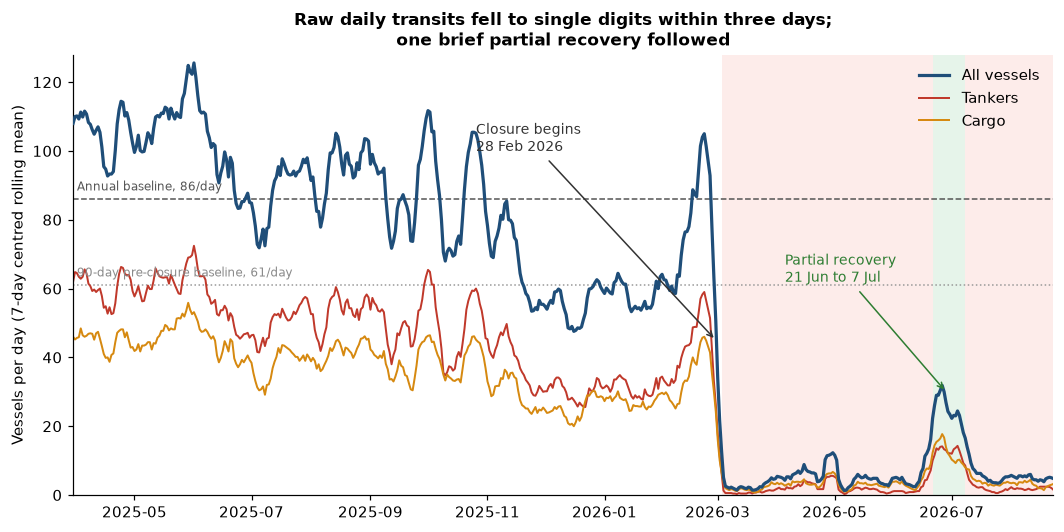

In [16]:
# 4.1 fig 1: the collapse in context
def regime_blocks(mask):
    idx = transits.index[mask]
    if len(idx) == 0:
        return []
    s = idx.to_series()
    grp = (s.diff() != pd.Timedelta(days=1)).cumsum()
    return [(g.min(), g.max()) for _, g in s.groupby(grp)]


fig, ax = plt.subplots(figsize=(11.5, 5.2))

for regime_name, shade in [("closure", "#fdecea"), ("partial recovery", "#e6f4ea")]:
    for start, end in regime_blocks(transits["regime"] == regime_name):
        ax.axvspan(start, end + pd.Timedelta(days=1), color=shade, lw=0, zorder=0)

roll_tanker = transits["n_tanker"].rolling(7, center=True, min_periods=4).mean()
roll_cargo = transits["n_cargo"].rolling(7, center=True, min_periods=4).mean()

ax.plot(transits.index, transits["roll7"], color="#1f4e79", lw=2.1, label="All vessels", zorder=3)
ax.plot(transits.index, roll_tanker, color="#c0392b", lw=1.3, label="Tankers", zorder=2)
ax.plot(transits.index, roll_cargo, color="#d68910", lw=1.3, label="Cargo", zorder=2)

ax.axhline(baseline_median, color="#555555", ls="--", lw=1, zorder=1)
ax.axhline(baseline_90d, color="#999999", ls=":", lw=1, zorder=1)
ax.text(transits.index[2], baseline_median + 2.5, f"Annual baseline, {baseline_median:.0f}/day", fontsize=8, color="#555555")
ax.text(transits.index[2], baseline_90d + 2.5, f"90-day pre-closure baseline, {baseline_90d:.0f}/day", fontsize=8, color="#8a8a8a")

ax.annotate(
    "Closure begins\n28 Feb 2026"
    , xy=(crisis_onset, 45)
    , xytext=(crisis_onset - pd.Timedelta(days=125), 100)
    , arrowprops=dict(arrowstyle="->", color="#333333", lw=1)
    , fontsize=9
    , color="#333333"
)
ax.annotate(
    "Partial recovery\n21 Jun to 7 Jul"
    , xy=(pd.Timestamp("2026-06-28"), 30)
    , xytext=(pd.Timestamp("2026-04-05"), 62)
    , arrowprops=dict(arrowstyle="->", color="#2e7d32", lw=1)
    , fontsize=9
    , color="#2e7d32"
)

ax.set_title("Raw daily transits fell to single digits within three days;\none brief partial recovery followed")
ax.set_ylabel("Vessels per day (7-day centred rolling mean)")
ax.set_ylim(0, 128)
ax.set_xlim(transits.index.min(), transits.index.max())
ax.legend(frameon=False, loc="upper right")

fig.savefig(fig_dir / "fig01_collapse_timeline.png")
plt.show()

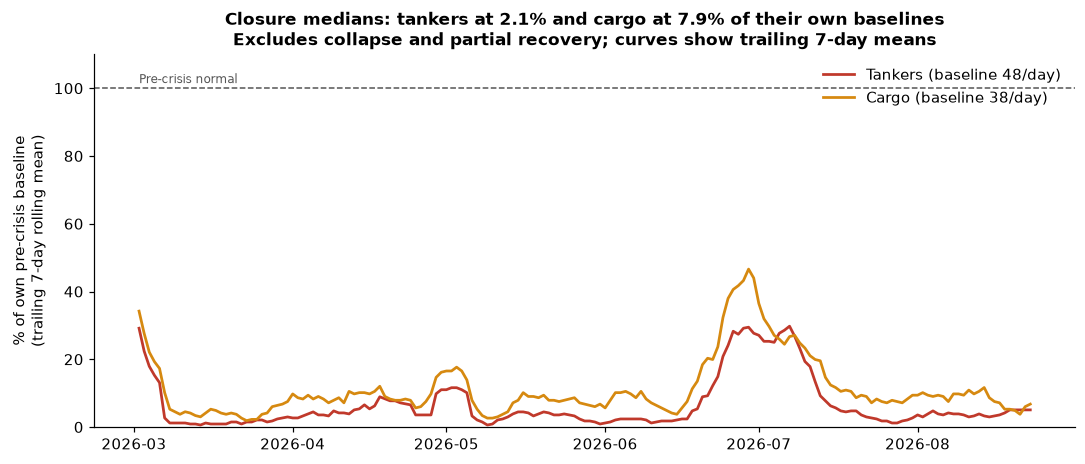

,pre_crisis_median,closure_median,recovery_median,closure_pct_of_pre,recovery_pct_of_pre
all,86.0,4.0,25.0,4.7,29.1
tanker,48.0,1.0,13.0,2.1,27.1
cargo,38.0,3.0,11.0,7.9,28.9


In [17]:
# 4.2 fig 2: each segment measured against its own pre-crisis baseline
tanker_base = transits.loc[:pre_crisis_end, "n_tanker"].median()
cargo_base = transits.loc[:pre_crisis_end, "n_cargo"].median()

post = transits.loc[transits.index >= crisis_onset].copy()
post["tanker_pct"] = 100 * post["n_tanker"].rolling(7, min_periods=3).mean() / tanker_base
post["cargo_pct"] = 100 * post["n_cargo"].rolling(7, min_periods=3).mean() / cargo_base

fig, ax = plt.subplots(figsize=(11.5, 4.4))
ax.plot(post.index, post["tanker_pct"], color="#c0392b", lw=1.8, label=f"Tankers (baseline {tanker_base:.0f}/day)")
ax.plot(post.index, post["cargo_pct"], color="#d68910", lw=1.8, label=f"Cargo (baseline {cargo_base:.0f}/day)")
ax.axhline(100, color="#555555", ls="--", lw=1)
ax.text(post.index[2], 101.5, "Pre-crisis normal", fontsize=8, color="#555555")

clo_mask = transits["regime"] == "closure"
tanker_floor = 100 * transits.loc[clo_mask, "n_tanker"].median() / tanker_base
cargo_floor = 100 * transits.loc[clo_mask, "n_cargo"].median() / cargo_base

ax.set_title(
    f"Closure medians: tankers at {tanker_floor:.1f}% and cargo at {cargo_floor:.1f}% of their own baselines\n"
    "Excludes collapse and partial recovery; curves show trailing 7-day means"
)
ax.set_ylabel("% of own pre-crisis baseline\n(trailing 7-day rolling mean)")
ax.set_ylim(0, 110)
ax.legend(frameon=False, loc="upper right")
fig.savefig(fig_dir / "fig02_segment_elasticity.png")
plt.show()

rq1 = pd.DataFrame({
    "pre_crisis_median": [transits.loc[:pre_crisis_end, c].median() for c in ["n_total", "n_tanker", "n_cargo"]]
    , "closure_median": [transits.loc[transits["regime"] == "closure", c].median() for c in ["n_total", "n_tanker", "n_cargo"]]
    , "recovery_median": [transits.loc[transits["regime"] == "partial recovery", c].median() for c in ["n_total", "n_tanker", "n_cargo"]]
}, index=["all", "tanker", "cargo"])
rq1["closure_pct_of_pre"] = (100 * rq1["closure_median"] / rq1["pre_crisis_median"]).round(1)
rq1["recovery_pct_of_pre"] = (100 * rq1["recovery_median"] / rq1["pre_crisis_median"]).round(1)
rq1.to_csv(out_dir / "rq1_segment_summary.csv")
display(rq1)

### RQ2. The accumulating shortfall

Daily shortfall against each baseline is summed across the 177 days from onset, including collapse and partial recovery. The result estimates missing crossings, not vessel waiting time or economic cost.

The annual anchor is 41% above the 90 day anchor. Plotting both shows how that choice affects the cumulative total. The shaded band represents sensitivity to baseline choice, not a confidence interval or a measured causal effect.

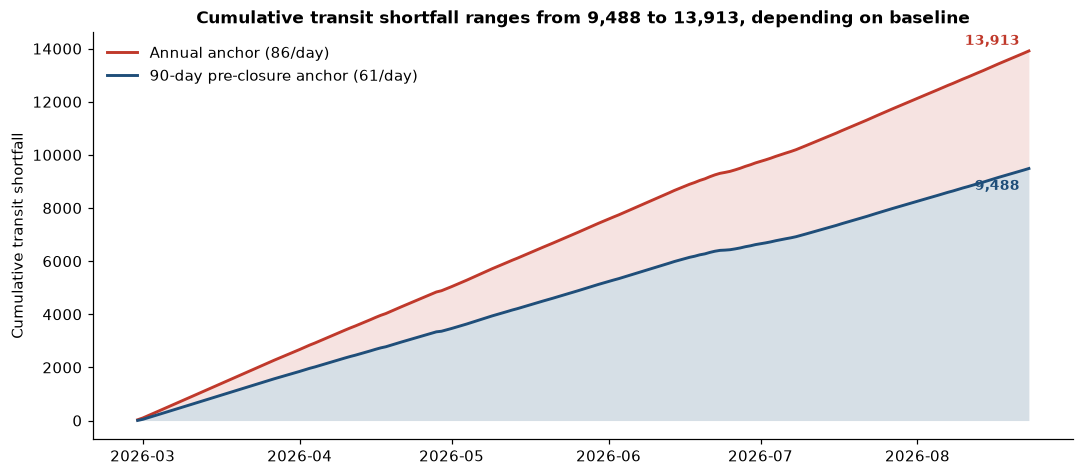

shaded band width at end : 4,425 transits attributable to anchor choice
mean shortfall, annual   : 78.6 transits per day
mean shortfall, 90-day   : 53.6 transits per day


In [18]:
# 4.3 fig 3: cumulative transit shortfall under both anchors
transits["cum_deficit_90d"] = (baseline_90d - transits["n_total"]).where(transits.index >= crisis_onset, 0).cumsum()

post = transits.loc[transits.index >= crisis_onset]

fig, ax = plt.subplots(figsize=(11.5, 4.8))
ax.fill_between(post.index, post["cum_deficit_90d"], color="#1f4e79", alpha=0.18, lw=0)
ax.fill_between(post.index, post["cum_deficit_90d"], post["cum_deficit"], color="#c0392b", alpha=0.14, lw=0)
ax.plot(post.index, post["cum_deficit"], color="#c0392b", lw=1.9, label=f"Annual anchor ({baseline_median:.0f}/day)")
ax.plot(post.index, post["cum_deficit_90d"], color="#1f4e79", lw=1.9, label=f"90-day pre-closure anchor ({baseline_90d:.0f}/day)")

final_hi = post["cum_deficit"].iloc[-1]
final_lo = post["cum_deficit_90d"].iloc[-1]
ax.annotate(f"{final_hi:,.0f}", xy=(post.index[-1], final_hi), xytext=(-6, 4), textcoords="offset points", fontsize=9, color="#c0392b", ha="right", fontweight="bold")
ax.annotate(f"{final_lo:,.0f}", xy=(post.index[-1], final_lo), xytext=(-6, -14), textcoords="offset points", fontsize=9, color="#1f4e79", ha="right", fontweight="bold")

ax.set_title(f"Cumulative transit shortfall ranges from {final_lo:,.0f} to {final_hi:,.0f}, depending on baseline")
ax.set_ylabel("Cumulative transit shortfall")
ax.legend(frameon=False, loc="upper left")
fig.savefig(fig_dir / "fig03_cumulative_deficit.png")
plt.show()

print(f"shaded band width at end : {final_hi - final_lo:,.0f} transits attributable to anchor choice")
print(f"mean shortfall, annual   : {final_hi / len(post):.1f} transits per day")
print(f"mean shortfall, 90-day   : {final_lo / len(post):.1f} transits per day")

### RQ3. Did the weekly rhythm survive?

The calendar heat map places complete weeks on the vertical axis and weekdays on the horizontal. The left panel uses a log scale because transit levels differ by more than an order of magnitude. Grey cells mark zero transit days. The right panel divides each day by its week's mean to compare patterns within weeks without the difference in level dominating the display.

The horizontal line marks the start of the week containing closure onset, not the exact date of 28 February. The supporting box plots and Kruskal Wallis tests compare weekday groups in the pre crisis and closure regimes. The closure tests exclude collapse and partial recovery. A non significant result does not establish that seasonality is absent, and serial dependence limits the interpretation.

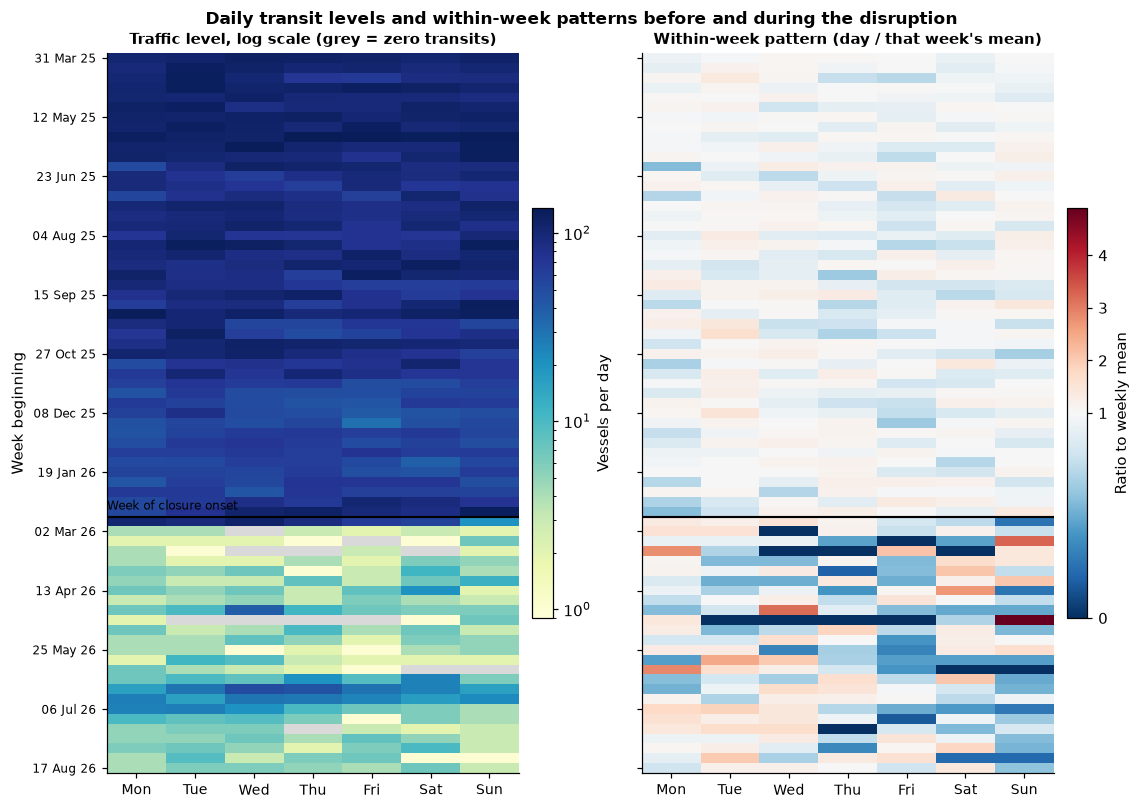

In [19]:
# 4.4 fig 4: calendar heat map, raw level and within-week normalised
cal = transits.copy()
cal["week_start"] = cal.index - pd.to_timedelta(cal["dow_num"], unit="D")

raw_piv = cal.pivot_table(index="week_start", columns="dow_num", values="n_total")
raw_piv = raw_piv.dropna(axis=0)
norm_piv = raw_piv.div(raw_piv.mean(axis=1), axis=0)

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
onset_week = crisis_onset - pd.Timedelta(days=int(crisis_onset.dayofweek))
onset_row = int(raw_piv.index.get_indexer([onset_week])[0])

# zeros are non-positive so lognorm masks them; give them their own colour
cmap_level = plt.get_cmap("YlGnBu").copy()
cmap_level.set_bad("#d9d9d9")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 8.5), sharey=True)

im0 = axes[0].imshow(
    raw_piv.values
    , aspect="auto"
    , cmap=cmap_level
    , norm=LogNorm(vmin=0.9, vmax=float(np.nanmax(raw_piv.values)))
    , interpolation="nearest"
)
axes[0].set_title("Traffic level, log scale (grey = zero transits)", fontsize=10)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.03, label="Vessels per day")

im1 = axes[1].imshow(
    norm_piv.values
    , aspect="auto"
    , cmap="RdBu_r"
    , norm=TwoSlopeNorm(vmin=0, vcenter=1, vmax=float(np.nanmax(norm_piv.values)))
    , interpolation="nearest"
)
axes[1].set_title("Within-week pattern (day / that week's mean)", fontsize=10)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.03, label="Ratio to weekly mean")

for ax in axes:
    ax.set_xticks(range(7), dow_labels, fontsize=9)
    ax.axhline(onset_row - 0.5, color="#000000", lw=1.4)

tick_rows = range(0, len(raw_piv), 6)
axes[0].set_yticks(list(tick_rows), [raw_piv.index[i].strftime("%d %b %y") for i in tick_rows], fontsize=8)
axes[0].set_ylabel("Week beginning")
axes[0].text(-0.5, onset_row - 1.2, "Week of closure onset", fontsize=8, color="#000000", ha="left")

fig.suptitle("Daily transit levels and within-week patterns before and during the disruption", fontsize=11, fontweight="bold", y=0.925)
fig.savefig(fig_dir / "fig04_calendar_heatmap.png")
plt.show()

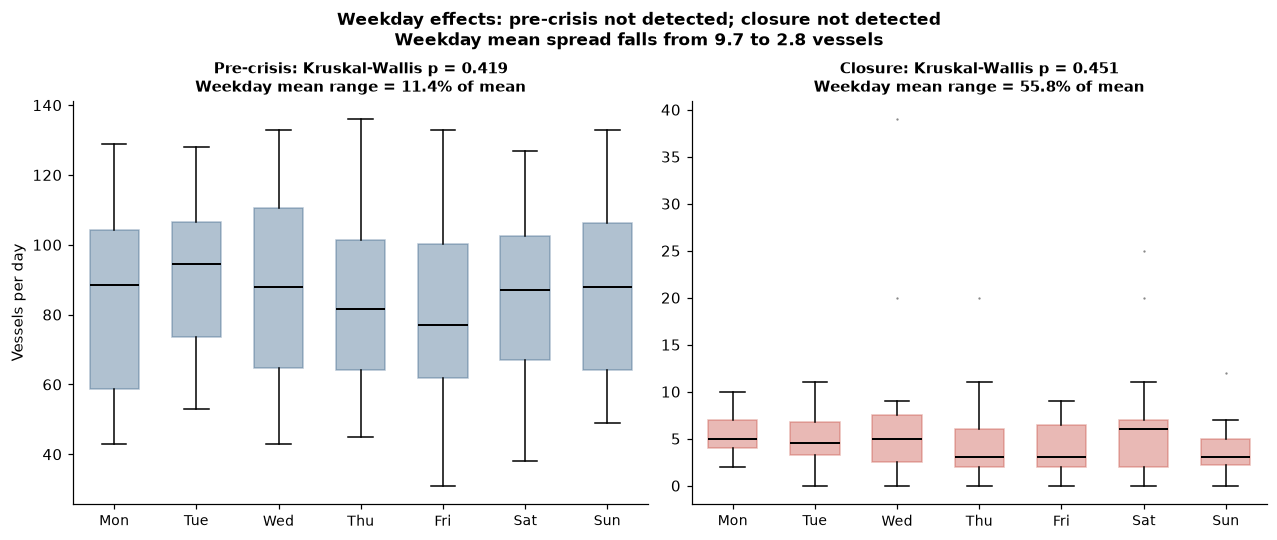

,regime,kruskal_h,p_value,min_dow_mean,max_dow_mean,spread_pct_of_mean
0,pre-crisis,6.04,0.4190,81.0,90.6,11.4
1,closure,5.76,0.4508,3.9,6.7,55.8


In [20]:
# 4.5 fig 5: day-of-week distributions before and during, with significance tests
pre = transits.loc[transits["regime"] == "pre-crisis"]
clo = transits.loc[transits["regime"] == "closure"]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), layout="constrained")
dow_stats = {}
for ax, (label, sub, colour) in zip(axes, [("Pre-crisis", pre, "#1f4e79"), ("Closure", clo, "#c0392b")]):
    data = [sub.loc[sub["dow_num"] == d, "n_total"].values for d in range(7)]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6, medianprops=dict(color="#000000", lw=1.3), flierprops=dict(marker=".", markersize=3, markerfacecolor="#888888", markeredgecolor="none"))
    for box in bp["boxes"]:
        box.set(facecolor=colour, alpha=0.35, edgecolor=colour)
    ax.set_xticks(range(1, 8), dow_labels, fontsize=9)
    stat, p = kruskal(*data)
    means = [float(np.mean(d)) for d in data]
    spread = 100 * (max(means) - min(means)) / float(np.mean(means))
    dow_stats[label] = (float(p), spread, max(means) - min(means))
    ax.set_title(f"{label}: Kruskal-Wallis p = {p:.3f}\nWeekday mean range = {spread:.1f}% of mean", fontsize=10)
    ax.set_ylabel("Vessels per day" if label == "Pre-crisis" else "")

sig = {k: ("detected" if v[0] < 0.05 else "not detected") for k, v in dow_stats.items()}
fig.suptitle(
    f"Weekday effects: pre-crisis {sig['Pre-crisis']}; closure {sig['Closure']}\n"
    f"Weekday mean spread falls from {dow_stats['Pre-crisis'][2]:.1f} to {dow_stats['Closure'][2]:.1f} vessels"
    , fontsize=11, fontweight="bold"
)
fig.savefig(fig_dir / "fig05_dow_distributions.png")
plt.show()

rq3 = []
for label, sub in [("pre-crisis", pre), ("closure", clo)]:
    data = [sub.loc[sub["dow_num"] == d, "n_total"].values for d in range(7)]
    means = [float(np.mean(d)) for d in data]
    stat, p = kruskal(*data)
    rq3.append({
        "regime": label
        , "kruskal_h": round(float(stat), 2)
        , "p_value": round(float(p), 4)
        , "min_dow_mean": round(min(means), 1)
        , "max_dow_mean": round(max(means), 1)
        , "spread_pct_of_mean": round(100 * (max(means) - min(means)) / np.mean(means), 1)
    })
rq3_tbl = pd.DataFrame(rq3)
rq3_tbl.to_csv(out_dir / "rq3_dow_tests.csv", index=False)
display(rq3_tbl)

### RQ4. Why did the shock unwind while the strait stayed shut?

The supplementary Brent series shows the price reaction missed by the supplied feed. Stacked panels share a timeline without placing price and transits on competing vertical scales. Brent peaked 103% above its pre closure median 38 days after onset. Recorded throughput remained low apart from a brief partial recovery.

The reversal chart shows each curve only from its respective extreme onward. Brent uses a trailing median of seven price observations relative to the raw price peak. Transits use a centred seven day mean relative to its trough. Because the price reference is a raw peak, the smoothed Brent curve need not start at zero. The chart states the latest observation date for each series.

A separate exponential fit estimates the half life of the price premium above the pre closure median after the peak. It describes the observed decline without identifying its cause.

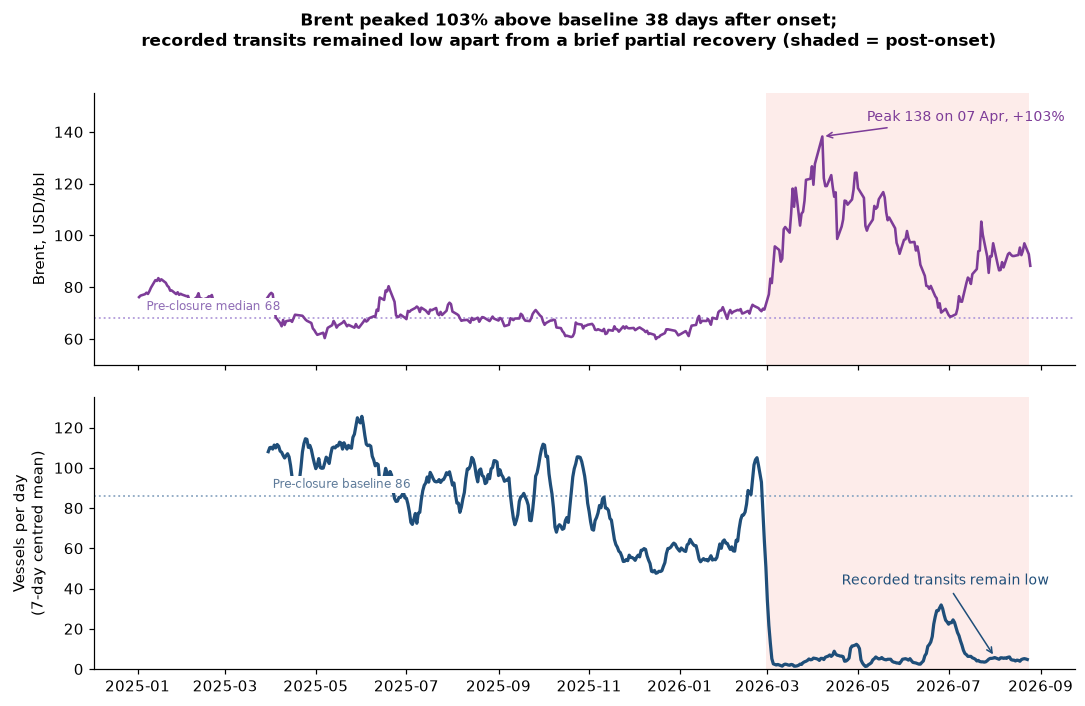

In [21]:
# 4.6 fig 7: price and throughput on a shared timeline, stacked to avoid dual-axis distortion
pre_price = brent_fred.loc[:pre_crisis_end, "brent"].median()
post_b = brent_fred.loc[crisis_onset:, "brent"]
peak_price = float(post_b.max())
peak_date = post_b.idxmax()

fig, axes = plt.subplots(2, 1, figsize=(11.5, 6.8), sharex=True, gridspec_kw={"height_ratios": [1, 1], "hspace": 0.12})

for ax in axes:
    for start, end in regime_blocks(transits["regime"].isin(["closure", "partial recovery", "collapse"])):
        ax.axvspan(start, end + pd.Timedelta(days=1), color="#fdecea", lw=0, zorder=0)

axes[0].plot(brent_fred.index, brent_fred["brent"], color="#7d3c98", lw=1.7, zorder=3)
axes[0].axhline(pre_price, color="#b39ddb", ls=":", lw=1.2, zorder=1)
axes[0].set_ylabel("Brent, USD/bbl")
axes[0].set_ylim(50, 155)
axes[0].annotate(
    f"Peak {peak_price:.0f} on {peak_date.strftime('%d %b')}, +{100 * (peak_price / pre_price - 1):.0f}%"
    , xy=(peak_date, peak_price)
    , xytext=(peak_date + pd.Timedelta(days=30), peak_price + 6)
    , arrowprops=dict(arrowstyle="->", color="#7d3c98", lw=1), fontsize=9, color="#7d3c98"
)
axes[0].text(brent_fred.index[3], pre_price + 3, f"Pre-closure median {pre_price:.0f}", fontsize=8, color="#8e6bb5", bbox=dict(facecolor="white", edgecolor="none", pad=1.2))

axes[1].plot(transits.index, transits["roll7"], color="#1f4e79", lw=2.1, zorder=3)
axes[1].axhline(baseline_median, color="#8fa9c4", ls=":", lw=1.2, zorder=1)
axes[1].set_ylabel("Vessels per day\n(7-day centred mean)")
axes[1].set_ylim(0, 135)
axes[1].text(transits.index[3], baseline_median + 4, f"Pre-closure baseline {baseline_median:.0f}", fontsize=8, color="#5d7a99", bbox=dict(facecolor="white", edgecolor="none", pad=1.2))
axes[1].annotate(
    "Recorded transits remain low"
    , xy=(pd.Timestamp("2026-08-01"), 6)
    , xytext=(pd.Timestamp("2026-04-20"), 42)
    , arrowprops=dict(arrowstyle="->", color="#1f4e79", lw=1), fontsize=9, color="#1f4e79"
)

fig.suptitle(
    f"Brent peaked {100 * (peak_price / pre_price - 1):.0f}% above baseline {(peak_date - crisis_onset).days} days after onset;\n"
    "recorded transits remained low apart from a brief partial recovery (shaded = post-onset)"
    , fontsize=11, fontweight="bold", y=0.99
)
fig.savefig(fig_dir / "fig07_price_vs_throughput.png")
plt.show()

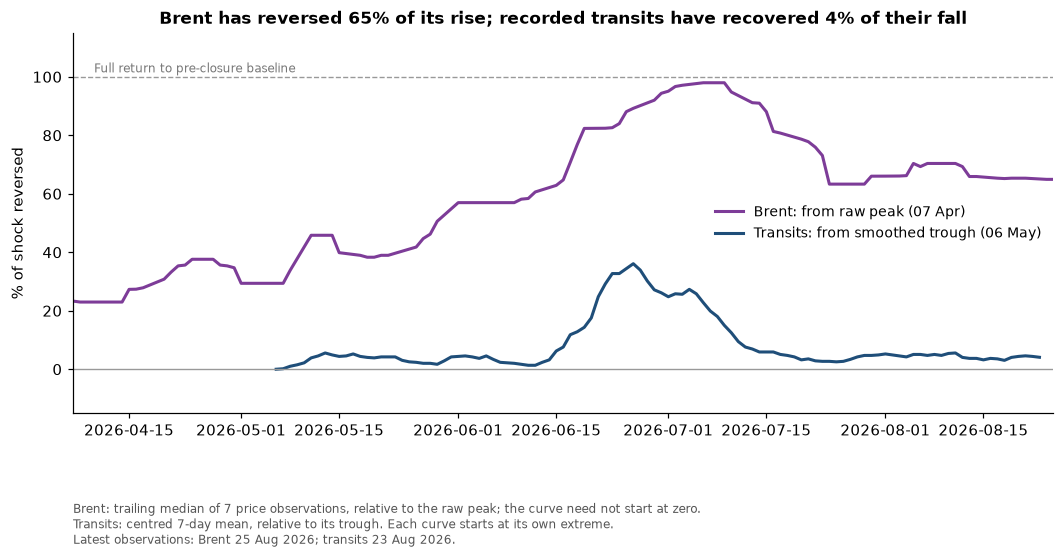

,value
pre-closure Brent median (USD),68.14
peak Brent (USD),138.21
peak date,2026-04-07
days from closure to peak,38
peak premium (USD),70.08
premium decay half-life (days),71.6
"price shock unwound, 7d smoothed (%)",64.9
"price shock unwound, last raw quote (%)",71.3
throughput shock unwound (%),4.1


In [22]:
# 4.7 fig 8: reversal after each series reaches its observed extreme
trough_roll = float(transits.loc[crisis_onset:, "roll7"].min())
trough_date = transits.loc[crisis_onset:, "roll7"].idxmin()

# retain the raw price peak as the reference while smoothing the observed price level
brent_smooth = brent_fred["brent"].rolling(7, min_periods=3).median()
end_date = max(transits.index.max(), brent_fred.index.max())

unwind = pd.DataFrame(index=pd.date_range(crisis_onset, end_date, freq="D"))
unwind["price_unwound"] = (100 * (peak_price - brent_smooth) / (peak_price - pre_price)).reindex(unwind.index).interpolate(limit_area="inside")
unwind["tput_unwound"] = (100 * (transits["roll7"] - trough_roll) / (baseline_median - trough_roll)).reindex(unwind.index)

# pre-extreme values measure an approaching shock, not a reversal
unwind.loc[unwind.index < peak_date, "price_unwound"] = np.nan
unwind.loc[unwind.index < trough_date, "tput_unwound"] = np.nan

fig, ax = plt.subplots(figsize=(11.5, 5.4))
ax.plot(unwind.index, unwind["price_unwound"], color="#7d3c98", lw=2.0, label=f"Brent: from raw peak ({peak_date:%d %b})")
ax.plot(unwind.index, unwind["tput_unwound"], color="#1f4e79", lw=2.0, label=f"Transits: from smoothed trough ({trough_date:%d %b})")
ax.axhline(0, color="#999999", lw=0.9)
ax.axhline(100, color="#999999", ls="--", lw=0.9)
plot_start = min(peak_date, trough_date)
ax.set_xlim(plot_start, end_date)
ax.text(plot_start + pd.Timedelta(days=3), 101.5, "Full return to pre-closure baseline", fontsize=8, color="#777777")

final_price = float(unwind["price_unwound"].dropna().iloc[-1])
final_tput = float(unwind["tput_unwound"].dropna().iloc[-1])
price_end_date = unwind["price_unwound"].last_valid_index()
tput_end_date = unwind["tput_unwound"].last_valid_index()
ax.set_title(f"Brent has reversed {final_price:.0f}% of its rise; recorded transits have recovered {final_tput:.0f}% of their fall")
ax.set_ylabel("% of shock reversed")
ax.set_ylim(-15, 115)
ax.legend(frameon=False, loc="center right", fontsize=9)
fig.text(
    0.125, 0.02
    , "Brent: trailing median of 7 price observations, relative to the raw peak; the curve need not start at zero.\n"
    "Transits: centred 7-day mean, relative to its trough. Each curve starts at its own extreme.\n"
    f"Latest observations: Brent {price_end_date:%d %b %Y}; transits {tput_end_date:%d %b %Y}."
    , fontsize=8, color="#555555"
)
fig.subplots_adjust(bottom=0.24)
fig.savefig(fig_dir / "fig08_shock_unwind.png")
plt.show()

# exponential decay half-life of the price premium measured from the peak
prem = (brent_fred.loc[peak_date:, "brent"] - pre_price)
prem = prem.loc[prem > 0]
t_days = (prem.index - peak_date).days.to_numpy(dtype=float)
slope, intercept = np.polyfit(t_days, np.log(prem.to_numpy(dtype=float)), 1)
half_life = -np.log(2) / slope

rq4 = {
    "pre-closure Brent median (USD)": round(pre_price, 2)
    , "peak Brent (USD)": round(peak_price, 2)
    , "peak date": peak_date.date().isoformat()
    , "days from closure to peak": int((peak_date - crisis_onset).days)
    , "peak premium (USD)": round(peak_price - pre_price, 2)
    , "premium decay half-life (days)": round(float(half_life), 1)
    , "price shock unwound, 7d smoothed (%)": round(final_price, 1)
    , "price shock unwound, last raw quote (%)": round(100 * (peak_price - float(brent_fred['brent'].iloc[-1])) / (peak_price - pre_price), 1)
    , "throughput shock unwound (%)": round(final_tput, 1)
}
rq4_tbl = pd.DataFrame.from_dict(rq4, orient="index", columns=["value"])
rq4_tbl.to_csv(out_dir / "rq4_shock_summary.csv")
display(rq4_tbl)

### RQ5. Lead, lag and regime structure

Trends or a shared break could inflate the correlation between price and throughput. The heat map compares levels and first differences over the full paired period and from 3 March onward. The latter includes partial recovery. Lags and differences follow successive paired observations after dates without prices are removed, so they are not measured in calendar days.

Weaker correlations after differencing suggest that trends or breaks contribute to the association in levels. They do not prove that the relationship is entirely spurious. The approximate noise thresholds neither account for serial dependence nor adjust for scanning 43 lags.

The autocorrelation panels compare daily transits before onset and from 28 February onward, including collapse and partial recovery. Their lags are calendar days. Differencing reduces persistence, but the panels alone cannot separate trend from other forms of dependence.

Parallel coordinates show the vessel mix and price profile across regimes. Prices are carried forward onto weekends and holidays, and zero transit days are excluded because tanker share is undefined. Individual days are drawn faintly, with regime medians overlaid and observed ranges labelled. The three observation collapse median is dashed.

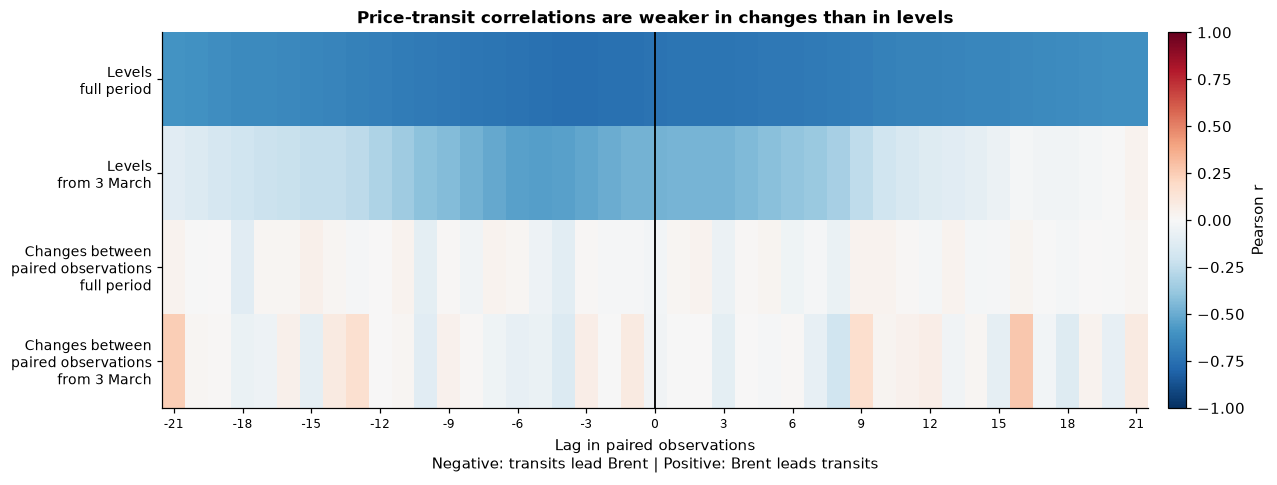

,r at lag 0,strongest r,at lag (paired observations),approx. 95% noise threshold
series,,,,
"Levels, full period",-0.740,-0.753,-4,0.104
"Levels, from 3 March",-0.472,-0.550,-5,0.179
"Changes between paired observations, full period",-0.029,-0.110,-18,0.104
"Changes between paired observations, from 3 March",-0.038,0.267,16,0.179


lags scanned per series: 43 | expected false positives at 95%: 2.1


In [23]:
# 4.8 fig 9: lag cross-correlation, levels vs differences
joint = pd.DataFrame({"transits": transits["n_total"], "brent": brent_fred["brent"]}).dropna()
joint["d_transits"] = joint["transits"].diff()
joint["d_brent"] = joint["brent"].diff()

closure_start = pd.Timestamp("2026-03-03")
lags = list(range(-21, 22))
specs = [
    ("Levels, full period", joint, "transits", "brent")
    , ("Levels, from 3 March", joint.loc[closure_start:], "transits", "brent")
    , ("Changes between paired observations, full period", joint, "d_transits", "d_brent")
    , ("Changes between paired observations, from 3 March", joint.loc[closure_start:], "d_transits", "d_brent")
]
cc = pd.DataFrame(
    [[df_[a].corr(df_[b].shift(k)) for k in lags] for _, df_, a, b in specs]
    , index=[s[0] for s in specs]
    , columns=lags
)

fig, ax = plt.subplots(figsize=(11.5, 4.3), layout="constrained")
im = ax.imshow(cc.values, aspect="auto", cmap="RdBu_r", norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1), interpolation="nearest")
ax.set_xticks(range(0, len(lags), 3), [lags[i] for i in range(0, len(lags), 3)], fontsize=8)
ax.set_yticks(range(len(cc)), [label.replace(", ", "\n", 1).replace("Changes between paired observations", "Changes between\npaired observations") for label in cc.index], fontsize=9)
ax.set_xlabel("Lag in paired observations\nNegative: transits lead Brent | Positive: Brent leads transits")
ax.axvline(lags.index(0), color="#000000", lw=1.2)
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="Pearson r")
ax.set_title("Price-transit correlations are weaker in changes than in levels")
fig.savefig(fig_dir / "fig09_lag_crosscorrelation.png")
plt.show()

best = pd.DataFrame([
    {
        "series": name
        , "r at lag 0": round(float(cc.loc[name, 0]), 3)
        , "strongest r": round(float(cc.loc[name].iloc[int(cc.loc[name].abs().to_numpy().argmax())]), 3)
        , "at lag (paired observations)": int(cc.columns[int(cc.loc[name].abs().to_numpy().argmax())])
        , "approx. 95% noise threshold": round(1.96 / np.sqrt(len(df_.dropna())), 3)
    }
    for (name, df_, _, _) in [(s[0], s[1], s[2], s[3]) for s in specs]
]).set_index("series")
display(best)

# 43 lags are scanned per row, so around two exceedances per row are expected by chance alone
print(f"lags scanned per series: {len(lags)} | expected false positives at 95%: {0.05 * len(lags):.1f}")

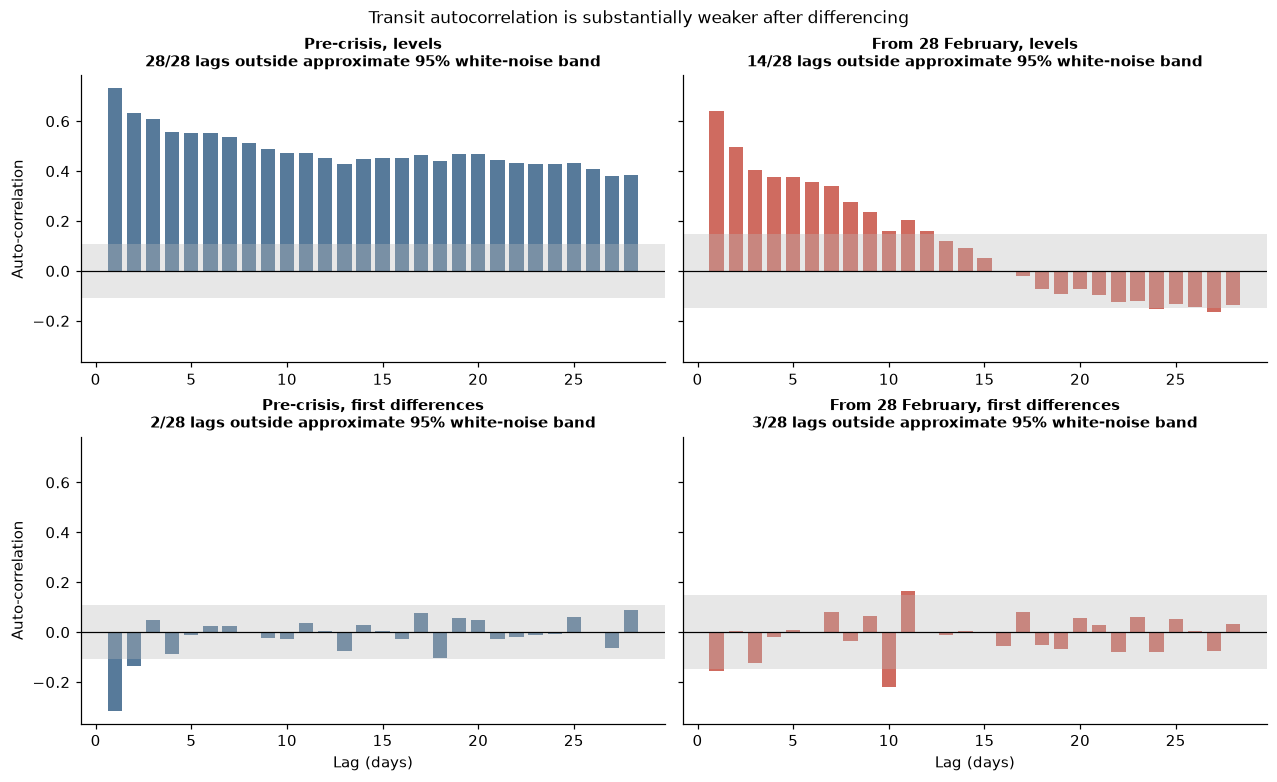

Pre-crisis, levels                   lag1 +0.731   lag7 +0.538   lag14 +0.447
From 28 February, levels             lag1 +0.641   lag7 +0.341   lag14 +0.090
Pre-crisis, first differences        lag1 -0.314   lag7 +0.024   lag14 +0.027
From 28 February, first differences  lag1 -0.156   lag7 +0.079   lag14 +0.006


In [24]:
# 4.9 fig 10: auto-correlation before and after onset, in levels and first differences
post_onset_series = transits.loc[crisis_onset:, "n_total"]
n_lags = 28

panels = [
    ("Pre-crisis, levels", pre["n_total"].to_numpy(dtype=float), "#1f4e79")
    , ("From 28 February, levels", post_onset_series.to_numpy(dtype=float), "#c0392b")
    , ("Pre-crisis, first differences", pre["n_total"].diff().dropna().to_numpy(dtype=float), "#1f4e79")
    , ("From 28 February, first differences", post_onset_series.diff().dropna().to_numpy(dtype=float), "#c0392b")
]

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.0), sharey=True, layout="constrained")
acf_store = {}
for ax, (label, series, colour) in zip(axes.ravel(), panels):
    vals = acf(series, nlags=n_lags, fft=False)
    ci = 1.96 / np.sqrt(len(series))
    acf_store[label] = vals
    ax.bar(range(1, n_lags + 1), vals[1:], color=colour, alpha=0.75, width=0.75)
    ax.axhspan(-ci, ci, color="#bbbbbb", alpha=0.35, lw=0)
    ax.axhline(0, color="#000000", lw=0.8)
    n_sig = int(np.sum(np.abs(vals[1:]) > ci))
    ax.set_title(f"{label}\n{n_sig}/{n_lags} lags outside approximate 95% white-noise band", fontsize=9.5)

for ax in axes[1]:
    ax.set_xlabel("Lag (days)")
for ax in axes[:, 0]:
    ax.set_ylabel("Auto-correlation")

fig.suptitle("Transit autocorrelation is substantially weaker after differencing", fontsize=11)
fig.savefig(fig_dir / "fig10_autocorrelation.png")
plt.show()

for label, vals in acf_store.items():
    print(f"{label:36s} lag1 {vals[1]:+.3f}   lag7 {vals[7]:+.3f}   lag14 {vals[14]:+.3f}")

days plotted: 500 of 512
excluded    : 12 zero-transit days where tanker share is undefined
regime
pre-crisis          335
closure             145
partial recovery     17
collapse              3


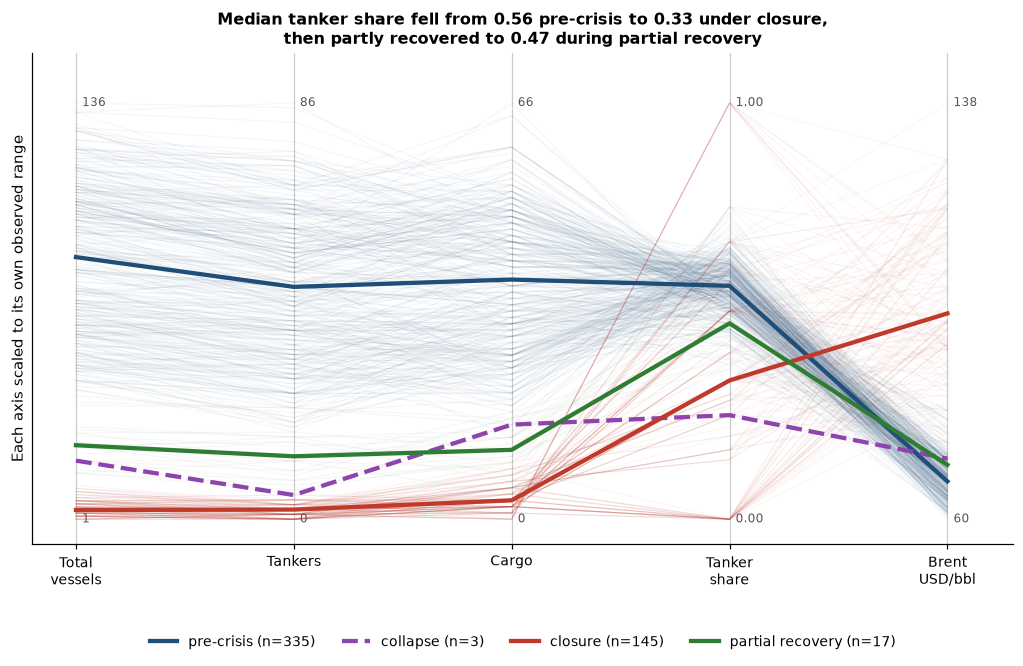

,n_total,n_tanker,n_cargo,tanker_share,brent
regime,,,,,
pre-crisis,86.0,48.0,38.0,0.56,67.05
collapse,20.0,5.0,15.0,0.25,71.32
closure,4.0,2.0,3.0,0.33,98.63
partial recovery,25.0,13.0,11.0,0.47,70.16


In [25]:
# 4.10 fig 11: parallel coordinates of the joint regime profile
# fred quotes business days only, so prices are carried forward onto weekends
brent_cal = brent_fred["brent"].reindex(pd.date_range(brent_fred.index.min(), brent_fred.index.max(), freq="D")).ffill()

pc_cols = ["n_total", "n_tanker", "n_cargo", "tanker_share", "brent"]
pc_labels = ["Total\nvessels", "Tankers", "Cargo", "Tanker\nshare", "Brent\nUSD/bbl"]

pc = transits.join(brent_cal.rename("brent"), how="inner")[pc_cols + ["regime"]].dropna()
pc_min, pc_max = pc[pc_cols].min(), pc[pc_cols].max()
pc_norm = (pc[pc_cols] - pc_min) / (pc_max - pc_min)

# tanker_share is undefined on zero-transit days, so the plot understates the extreme
n_zero = int((transits["n_total"] == 0).sum())
print(f"days plotted: {len(pc)} of {len(transits)}")
print(f"excluded    : {n_zero} zero-transit days where tanker share is undefined")
print(pc["regime"].value_counts().to_string())

regime_colour = {"pre-crisis": "#1f4e79", "collapse": "#8e44ad", "closure": "#c0392b", "partial recovery": "#2e7d32"}
x = np.arange(len(pc_cols))

fig, ax = plt.subplots(figsize=(11.5, 5.8))
for regime_name, colour in regime_colour.items():
    rows = pc_norm.loc[pc["regime"] == regime_name]
    for _, r in rows.iterrows():
        ax.plot(x, r.to_numpy(), color=colour, alpha=0.05, lw=0.7, zorder=1)

for regime_name, colour in regime_colour.items():
    rows = pc_norm.loc[pc["regime"] == regime_name]
    if rows.empty:
        continue
    n = len(rows)
    # a short transition is drawn dashed to distinguish its small sample
    ax.plot(x, rows.median().to_numpy(), color=colour, lw=2.8, zorder=3, ls="--" if n < 10 else "-", label=f"{regime_name} (n={n})")

for xi, col in zip(x, pc_cols):
    ax.axvline(xi, color="#cccccc", lw=0.8, zorder=0)
    ax.annotate(f"{pc_max[col]:.0f}" if pc_max[col] >= 2 else f"{pc_max[col]:.2f}", xy=(xi, 1.0), xytext=(4, 0), textcoords="offset points", fontsize=8, color="#555555", va="center")
    ax.annotate(f"{pc_min[col]:.0f}" if pc_max[col] >= 2 else f"{pc_min[col]:.2f}", xy=(xi, 0.0), xytext=(4, 0), textcoords="offset points", fontsize=8, color="#555555", va="center")

ax.set_xticks(x, pc_labels, fontsize=9)
ax.set_yticks([])
ax.set_ylabel("Each axis scaled to its own observed range")
ax.set_xlim(-0.2, len(pc_cols) - 0.7)
ax.set_ylim(-0.06, 1.12)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=4, fontsize=9)

profile = pc.groupby("regime", observed=True)[pc_cols].median().reindex(regime_order).round(2)
share_pre = float(profile.loc["pre-crisis", "tanker_share"])
share_clo = float(profile.loc["closure", "tanker_share"])
share_rec = float(profile.loc["partial recovery", "tanker_share"])
ax.set_title(
    f"Median tanker share fell from {share_pre:.2f} pre-crisis to {share_clo:.2f} under closure,\n"
    f"then partly recovered to {share_rec:.2f} during partial recovery"
    , fontsize=10.5
)
fig.savefig(fig_dir / "fig11_parallel_coordinates.png")
plt.show()

profile.to_csv(out_dir / "rq5_regime_profile.csv")
display(profile)

## 5. Conclusion and evaluation

### 5.1 Key findings

**RQ1.** Raw daily transits fell from 57 on 28 February to 4 on 2 March. During the closure regime, median throughput was 4.7% of the pre closure baseline. Tanker and cargo medians were 2.1% and 7.9% of their own baselines, so tanker traffic fell proportionally further. During partial recovery, the segments reached similar proportions of baseline, at 27.1% and 28.9%.

**RQ2.** Cumulative shortfall reached 9,488 transits under the 90 day anchor and 13,913 under the annual anchor across 177 days from onset. These totals average 53.6 and 78.6 transits per day. The difference reflects baseline choice, not an estimate of the closure's causal effect or an economic cost.

**RQ3.** Kruskal Wallis tests detected no weekday effect before closure (p = 0.419) or during the closure regime (p = 0.451). Relative weekday spread rose from 11.4% to 55.8% of the mean, while absolute spread fell from 9.7 vessels to 2.8 and mean traffic fell from about 85 to 5. The larger relative spread does not establish a new weekly pattern. The tests do not prove that seasonality was absent, particularly given serial dependence.

**RQ4.** Brent peaked at 138.21 USD on 7 April, 103% above its pre closure median of 68.14 and 38 days after onset. An exponential fit to the subsequent premium gives an estimated half life of 71.6 days. Brent reversed 65% of its rise using a rolling median of seven price observations, or 71% using the last raw quote. Recorded throughput recovered 4.1% of its fall. These are descriptive comparisons, not evidence that the closure alone caused the price path.

**RQ5.** The full period correlation at lag zero weakened from -0.740 in levels to -0.029 in changes. Some differenced correlations exceed the approximate noise thresholds, but those thresholds do not adjust for serial dependence or scanning 43 lags. The results do not establish a reliable predictive relationship. Transit autocorrelation is also weaker after differencing, without ruling out other dependence. Median tanker share fell from 0.56 to 0.33 under closure, then partly recovered to 0.47.

### 5.2 Evaluating the process

Auditing coverage before choosing the questions ruled out event mapping, linking news to transit changes and testing the index for advance warning. The initial price gap required a supplementary series rather than an assumption about the missing reaction.

Carrying two baselines changed the estimated shortfall by 4,425 transits. Showing both makes that sensitivity visible without claiming to separate the closure's effect from the earlier decline.

Comparing levels with differences changed the interpretation of price association and transit persistence. Both are stronger in levels. Differencing provides a check on the influence of trends and breaks, rather than proof that no relationship remains.

The figures were revised after inspecting their rendered output. Stacked panels replaced a dual axis chart whose price reference line could be mistaken for a throughput reference. Parallel coordinate axes were labelled with observed ranges. The reversal chart now starts each curve at its relevant extreme, and lag labels distinguish paired observations from calendar days.

### 5.3 Limitations

**AIS visibility limits the throughput measure.** Transit counts derive from AIS broadcasts and may miss vessels that disable their transponders. If substantial traffic moved without broadcasting, recorded throughput would understate actual movements. The events file mentions shadow fleet activity and ship to ship transfers, but its coverage is too limited to quantify any bias. The observed divergence is between price and AIS recorded traffic.

**No causal claim is available.** This observational study has no comparison chokepoint. Global demand, inventory policy and OPEC decisions could affect prices but are not measured here.

**The pre closure series trends downward.** Quarterly medians fall from 107.0 to 63.5 across the eleven months before onset. Neither baseline replaces a model of that trend.

**The price sources measure different instruments.** The primary feed begins nine weeks after onset. Thirty percent of its quotes repeat the previous value, including one run of 145 identical observations. FRED provides the earlier history and agrees with the primary feed across 76 overlapping days, with r = 0.9675 and a mean absolute difference of 2.95 USD. It nevertheless measures spot prices rather than front month futures and follows a business day calendar.

**Zero transit days are absent from the parallel coordinates.** Tanker share is undefined on those twelve days, so they are excluded. The plotted regime profiles therefore do not include all transit observations.

### 5.4 Further work

Comparing AIS transit counts with import volumes or terminal throughput could test whether unobserved shipping helps explain the price and traffic divergence. Similar movements would support the recorded pattern. A recovery in volumes without a corresponding rise in AIS counts could indicate traffic the series misses.

Adding comparison chokepoints could support a difference in differences design to distinguish the Hormuz disruption from wider changes. Modelling the transit counts directly would also suit data that are overdispersed and bounded at zero.